In [8]:
import pandas as pd 
import numpy as np 
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [9]:
data = pd.read_csv(Path(Path().cwd(), "models/2025-07-22 B7H4 SAM 1000L Model/AR25-050_051_068 Model Data.csv"))
data.head()

,Sample_Name,Experiment,Batch,Sample_Time,Day,Vicell_sampletime,Flex_sampletime,Cedex_sampletime,TCC,VCC,...,DO,pH_setpoint,pH_setpoint_low,pH_setpoint_high,Temperature_setpoint,Feed_Time_Offset,Bolus_Feed,Normalized_Bolus_Feed,Volume,Initial_Volume
0,AR25-050005152FER2050-01,AR25-050,AR25-050-001,5/15/2025 14:32,0,5/15/2025 14:12,5/15/2025 14:32,5/15/2025 15:40,0.6130,0.6036,...,40,7.1,6.95,7.25,36.5,0,0.0,0.000000,189.01,190
1,AR25-050005162FER2050-01,AR25-050,AR25-050-001,5/16/2025 11:06,1,5/16/2025 11:49,5/16/2025 11:06,5/16/2025 13:46,0.9632,0.9582,...,40,7.1,6.95,7.25,36.5,0,0.0,0.000000,185.22,190
2,AR25-050005172FER2050-01,AR25-050,AR25-050-001,5/17/2025 11:07,2,5/17/2025 11:44,5/17/2025 11:07,5/17/2025 14:49,2.0593,2.0535,...,40,7.1,6.95,7.25,36.5,0,0.0,0.000000,182.40,190
3,AR25-050005182FER2050-01,AR25-050,AR25-050-001,5/18/2025 11:06,3,5/18/2025 13:26,5/18/2025 11:06,5/18/2025 13:26,3.9400,3.9300,...,40,7.1,6.95,7.25,36.5,0,0.0,0.000000,176.79,190
4,AR25-050005192FER2050-01,AR25-050,AR25-050-001,5/19/2025 11:06,4,5/19/2025 11:24,5/19/2025 11:06,5/19/2025 12:55,7.2423,7.2028,...,40,7.1,6.95,7.25,36.5,0,9.5,0.054039,175.80,190


In [10]:
discard_batches = [
    "AR25-050-010",
    "AR25-050-012",
    "AR25-050-016",
    "AR25-050-021",
    "AR25-050-022",
    "AR25-051-001",
    "AR25-051-010"
]

training_columns = [
    "Day",
    "Batch",
    # "TCC",
    "VCC",
    "Viability",
    "Diameter",
    # "Osmolality",
    "Ammonium",
    # "Calcium",
    "Glucose",
    # "Glutamine",
    "Glutamate",
    # "Lactate",
    # "Potassium",
    # "Sodium",
    # "Bicarbonate",
    # "pCO2 at Temp",
    # "pO2 at Temp",
    "pH at Temp",
    "IGG",
]

In [11]:
batch_mask = data["Batch"].isin(discard_batches)
regression_data = data.loc[batch_mask, training_columns]
grouped = regression_data.groupby("Batch", group_keys=False, as_index=False)
df_interpolate = grouped.apply(
    lambda group: group.interpolate(method="linear", limit_direction="forward")
)

training_columns.remove("Day")
training_columns.remove("Batch")
X = df_interpolate.loc[data["Day"]!=14, training_columns]
y = df_interpolate.loc[data["Day"]!=0, "IGG"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

C:\Users\zah48132\AppData\Local\Temp\ipykernel_44832\3717336394.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda group: group.interpolate(method="linear", limit_direction="forward")
C:\Users\zah48132\AppData\Local\Temp\ipykernel_44832\3717336394.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda group: group.interpolate(method="linear", limit_direction="forward")
C:\Users\zah48132\AppData\Local\Temp\ipykernel_44832\3717336394.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda group: group.interpolate(method="linear", limit_direction="forward")
C:\Users\zah48132\AppData\Local\Temp\ipykernel

In [12]:
pipeline_ = Pipeline(
    [("scaler", MinMaxScaler()), ("rfe", RFE(estimator=LinearRegression(), n_features_to_select=5, step=1))]
)

In [13]:
pipeline_.fit(X=X_train, y=y_train)

best_features = []
for label, rank in zip(training_columns, pipeline_.named_steps["rfe"].ranking_):
    if rank == 1:
        best_features.append(label)

for label, coef in zip(best_features, pipeline_.named_steps["rfe"].estimator_.coef_):
    print(f"{label:<15}: {coef: .2f}")

VCC            :  173.85
Viability      : -9.66
Ammonium       :  157.76
Glutamate      : -69.47
IGG            :  1061.32


Text(0.5, 1.0, 'R2:  0.979')

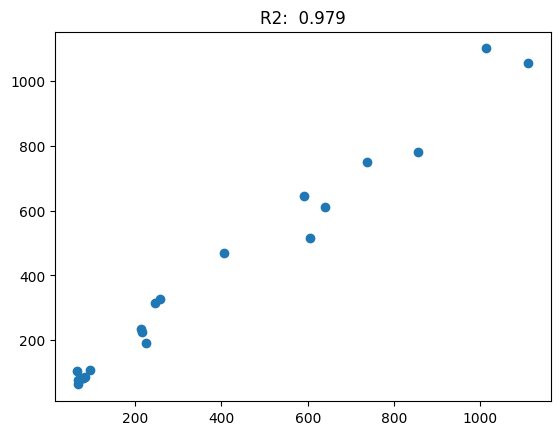

In [14]:
predictions = pipeline_.predict(X_test)
plt.scatter(y_test, predictions)
score_ = r2_score(y_test, predictions)
plt.title(f"R2: {score_: 0.3f}")